In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from ipywidgets import interactive, IntSlider
from IPython.display import Markdown, display, Latex



In [2]:
# Alleen train inladen
df = pd.read_csv("data_train.csv", sep=",", decimal=".")


In [3]:
# Scheiden van target en input variabelen
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

X.shape, y.shape

((1995, 9), (1995,))

In [4]:
# Er is maar een categorische variabelen waar we OneHotEncoder op kunnen gebruiken namelijk Age group, 
# ookal is dit eigenlijk niet nodig omdat we ook een numerieke Age variabelen in de dataset hebben, maar de opdracht zei dat het moest...
cat_cols = ["Age Group"]
num_cols = [c for c in X.columns if c not in cat_cols]

In [5]:
# ColumnTransformer voor OneHotEncoder en StandardScaler voor de overige numerieke variabelen
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [6]:
# Hier maken we de pipline aan 
prep_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])
prep_pipeline

,steps,"[('preprocessing', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
# Hier stoppen we X (input variabelen) in onze pipeline en leert de pipeline hoe hij deze moet schalen/encoden
X_prepared = prep_pipeline.fit_transform(X)
X_prepared.shape

(1995, 13)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [10]:
from sklearn.model_selection import GridSearchCV

mtry = [2,3,4,5,6,7,8,9,10,20,30]

gridsearch_rf = GridSearchCV(
    rf_pipe,
    param_grid={"model__max_features": mtry},
    scoring="roc_auc",
    n_jobs=-1
)

gridsearch_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_features': [2, 3, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [11]:
mtry = [2,3,4,5,6,7,8,9,10,20,30]

gridsearch_rf = GridSearchCV(
    rf_pipe,
    param_grid={"model__max_features": mtry},
    scoring="roc_auc",
    n_jobs=-1
)

gridsearch_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_features': [2, 3, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [12]:
print("Beste parameter:", gridsearch_rf.best_params_)
print("Beste AUC:", gridsearch_rf.best_score_)

Beste parameter: {'model__max_features': 2}
Beste AUC: 0.9822878511433718


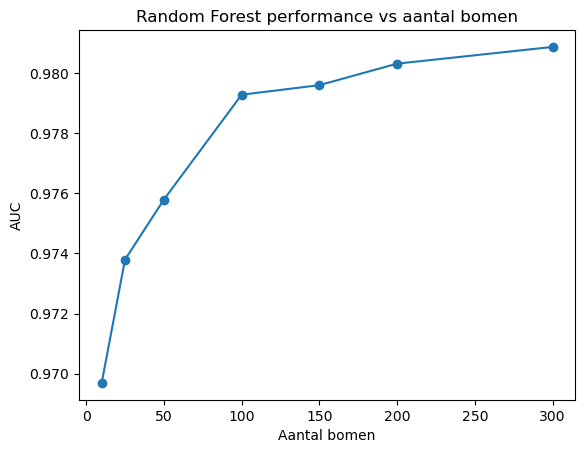

In [13]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

n_trees = [10, 25, 50, 100, 150, 200, 300]

auc_scores = []

for n in n_trees:
    
    rf_pipe.set_params(model__n_estimators=n)
    
    rf_pipe.fit(X_train, y_train)
    
    p_pred = rf_pipe.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_test, p_pred)
    
    auc_scores.append(auc)

plt.plot(n_trees, auc_scores, marker='o')
plt.xlabel("Aantal bomen")
plt.ylabel("AUC")
plt.title("Random Forest performance vs aantal bomen")
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns

mtry = [2,3,4,5,6,7,8,9,10,15,20]

rf_pipe.set_params(
    model__n_estimators = 200
)

gridsearch_rf = GridSearchCV(
    rf_pipe,
    param_grid = {'model__max_features': mtry},
    scoring = 'roc_auc',
    cv = 5,
    n_jobs = -1
)

gridsearch_rf.fit(X_train, y_train)

best_m = gridsearch_rf.best_params_['model__max_features']
best_score = gridsearch_rf.best_score_

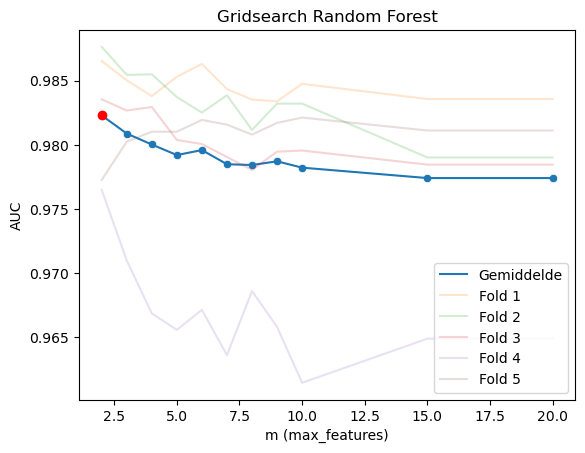

In [15]:
sns.lineplot(
    gridsearch_rf.cv_results_,
    x='param_model__max_features',
    y='mean_test_score',
    label='Gemiddelde'
)

sns.scatterplot(
    gridsearch_rf.cv_results_,
    x='param_model__max_features',
    y='mean_test_score'
)

for i in range(5):
    
    sns.lineplot(
        gridsearch_rf.cv_results_,
        x='param_model__max_features',
        y=f'split{i}_test_score',
        alpha=0.2,
        label=f'Fold {i+1}'
    )

plt.plot(best_m, best_score, 'ro')

plt.xlabel("m (max_features)")
plt.ylabel("AUC")
plt.title("Gridsearch Random Forest")
plt.show()

<Figure size 1600x400 with 0 Axes>

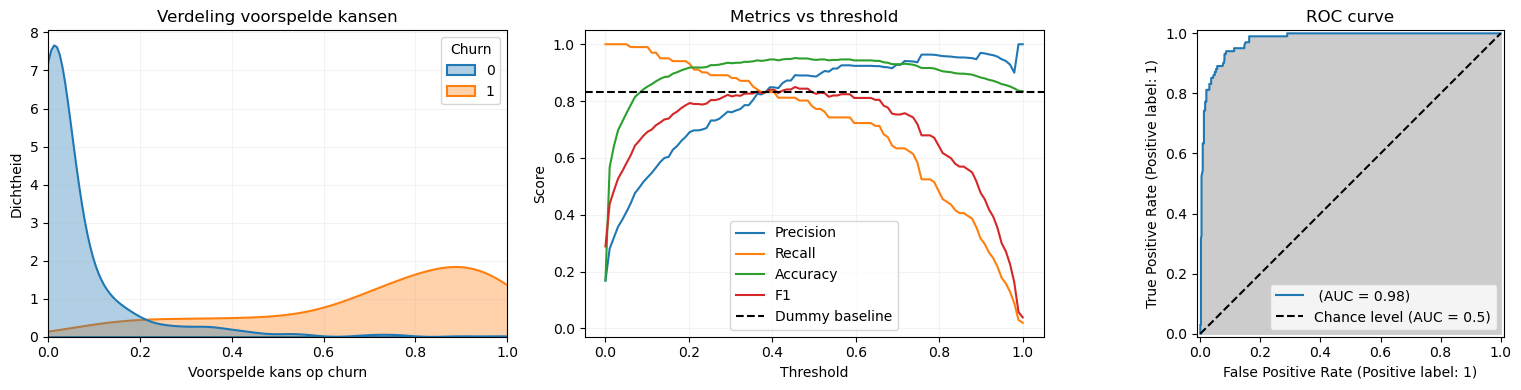

In [31]:


dummy = DummyClassifier(strategy="most_frequent", random_state=2026)

dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_dummy)

best_model = gridsearch_rf.best_estimator_

p_pred = best_model.predict_proba(X_test)[:,1]

df = pd.DataFrame({
    "p_pred": p_pred,
    "Churn": y_test
})

plt.figure(figsize=(16,4))
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    RocCurveDisplay
)

df = pd.DataFrame({
    "p_pred": p_pred,
    "Churn": y_test
})

plt.figure(figsize=(16,4))

# ---------------------------------------------------
# 1. Verdeling voorspelde kansen
# ---------------------------------------------------

ax = plt.subplot(1,3,1)

sns.kdeplot(
    data=df,
    x="p_pred",
    hue="Churn",
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=1.5,
    ax=ax
)

ax.set_xlim(0,1)
ax.set_title("Verdeling voorspelde kansen")
ax.set_xlabel("Voorspelde kans op churn")
ax.set_ylabel("Dichtheid")
ax.grid(alpha=0.15)


# ---------------------------------------------------
# 2. Metrics vs threshold
# ---------------------------------------------------

ax = plt.subplot(1,3,2)

thresholds = np.linspace(0,1,100)

precision = []
recall = []
accuracy = []
f1 = []

for t in thresholds:
    
    y_pred = (p_pred >= t).astype(int)
    
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    accuracy.append(accuracy_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))

ax.plot(thresholds, precision, label="Precision")
ax.plot(thresholds, recall, label="Recall")
ax.plot(thresholds, accuracy, label="Accuracy")
ax.plot(thresholds, f1, label="F1")

# Dummy baseline
ax.axhline(dummy_acc, linestyle="--", color="black", label="Dummy baseline")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs threshold")
ax.legend()
ax.grid(alpha=0.15)


# ---------------------------------------------------
# 3. ROC curve
# ---------------------------------------------------

ax = plt.subplot(1,3,3)

roc = RocCurveDisplay.from_predictions(
    y_test,
    p_pred,
    name='',
    plot_chance_level=True,
    ax=ax
)

plt.fill_between(roc.fpr, roc.tpr, color='0.8')

ax.set_title("ROC curve")

plt.tight_layout()
plt.show()